In [1]:
# MASK R-CNN FROM SCRATCH — labels 1-5, background=0

In [2]:
import os, gc, json, time, random, numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import cv2, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import torchvision.transforms.functional as F
from tqdm import tqdm
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# =========================================================
# PATHS — scratch uses a SMALL balanced subset for speed
# =========================================================
import random
from collections import defaultdict

PRUNED_PATH  = "/kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset"
PREPROC_PATH = "/kaggle/input/datasets/harshitabansal307/task2-preprocessed-detetcion-segmentation/preprocessed"

train_pt = os.path.join(PREPROC_PATH, "train_detection_samples_balanced.pt")
val_pt   = os.path.join(PREPROC_PATH, "val_detection_samples_balanced.pt")

train_data_full = torch.load(train_pt, map_location="cpu")
val_data_full   = torch.load(val_pt,   map_location="cpu")

# ── SMALL SUBSET FOR SCRATCH (fast training) ──
# 20k is too slow for scratch — use 2000 train / 600 val
TRAIN_TARGET = 2000
VAL_TARGET   = 600

CLASS_NAMES_TEMP = ["__background__","short_sleeve_top","trousers",
                    "shorts","long_sleeve_top","skirt"]

def build_small_balanced_subset(data, target_size):
    class_buckets = defaultdict(list)
    for sample in data:
        for label in set(sample["labels"]):
            class_buckets[int(label)].append(sample)
    classes   = sorted(class_buckets.keys())
    per_class = target_size // len(classes)
    subset = []
    for c in classes:
        bucket = class_buckets[c]
        random.shuffle(bucket)
        subset.extend(bucket[:per_class])
    random.shuffle(subset)
    seen, unique = set(), []
    for s in subset:
        if s["img_path"] not in seen:
            seen.add(s["img_path"])
            unique.append(s)
    return unique[:target_size]

train_data = build_small_balanced_subset(train_data_full, TRAIN_TARGET)
val_data   = build_small_balanced_subset(val_data_full,   VAL_TARGET)

print(f"Train samples: {len(train_data)} (subset for scratch speed)")
print(f"Val samples:   {len(val_data)}")
all_lbls = [l for s in train_data for l in s["labels"]]
print(f"Label range:   {min(all_lbls)} - {max(all_lbls)} (should be 1-5)")


Train samples: 1945 (subset for scratch speed)
Val samples:   585
Label range:   1 - 5 (should be 1-5)


In [4]:
# =========================================================
# CATEGORY MAP
# Labels in .pt files are ALREADY 1-5 (from new preprocessing)
# Background = 0 (implicit, not annotated)
# No remapping needed — just passthrough
# =========================================================
CATEGORY_MAP = {1:1, 2:2, 3:3, 4:4, 5:5}

NUM_CLASSES = 5

CLASS_NAMES = [
    "__background__",   # 0
    "short_sleeve_top", # 1
    "trousers",         # 2
    "shorts",           # 3
    "long_sleeve_top",  # 4
    "skirt",            # 5
]

label_map = {
    "short sleeve top": 1,
    "trousers":         2,
    "shorts":           3,
    "long sleeve top":  4,
    "skirt":            5,
}
with open("/kaggle/working/label_map.json", "w") as f:
    json.dump(label_map, f, indent=4)
print("label_map.json saved")
print("Category map:", CATEGORY_MAP)

label_map.json saved
Category map: {1: 1, 2: 2, 3: 3, 4: 4, 5: 5}


In [5]:
# =========================================================
# POLYGON → BINARY MASK (per instance)
# Scales polygon coordinates to resized image dimensions
# =========================================================
def polygon_to_mask(poly_list, h, w, scale_x=1.0, scale_y=1.0):
    mask = np.zeros((h, w), dtype=np.uint8)
    for poly in poly_list:
        pts = np.array(poly).reshape(-1, 2).astype(np.float32)
        pts[:, 0] *= scale_x
        pts[:, 1] *= scale_y
        pts = pts.astype(np.int32)
        cv2.fillPoly(mask, [pts], 1)   # binary: 1=clothing pixel, 0=background
    return mask

In [6]:
# =========================================================
# DATASET
# Target dict per image:
#   boxes    : FloatTensor [N,4]  x1,y1,x2,y2
#   labels   : Int64Tensor [N]    values 1-5
#   masks    : UInt8Tensor [N,H,W] binary per instance
#   image_id : Int64Tensor [1]
#   area     : FloatTensor [N]
#   iscrowd  : Int64Tensor [N]
# =========================================================
class DeepFashionMRCNN(Dataset):

    def __init__(self, data, augment=True):
        self.data    = data
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]

        img = cv2.imread(sample["img_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = img.shape[:2]

        img = cv2.resize(img, (512, 512))
        h, w = 512, 512
        scale_x = w / orig_w
        scale_y = h / orig_h

        flip = self.augment and random.random() > 0.5
        if flip:
            img = np.fliplr(img).copy()

        boxes, labels, masks, areas = [], [], [], []

        for raw_label, poly_list in zip(sample["labels"], sample["polygons"]):
            cls = CATEGORY_MAP.get(int(raw_label))
            if cls is None:
                continue

            mask = polygon_to_mask(poly_list, h, w, scale_x, scale_y)
            if flip:
                mask = np.fliplr(mask).copy()

            ys, xs = np.where(mask)
            if len(xs) == 0:
                continue

            x1, x2 = int(xs.min()), int(xs.max())
            y1, y2 = int(ys.min()), int(ys.max())

            if x2 <= x1 or y2 <= y1:
                continue

            boxes.append([x1, y1, x2, y2])
            labels.append(cls)
            masks.append(mask)
            areas.append((x2 - x1) * (y2 - y1))

        img_tensor = F.to_tensor(Image.fromarray(img))

        if len(boxes) == 0:
            target = {
                "boxes":    torch.zeros((0, 4), dtype=torch.float32),
                "labels":   torch.zeros((0,),   dtype=torch.int64),
                "masks":    torch.zeros((0, h, w), dtype=torch.uint8),
                "image_id": torch.tensor([idx],  dtype=torch.int64),
                "area":     torch.zeros((0,),    dtype=torch.float32),
                "iscrowd":  torch.zeros((0,),    dtype=torch.int64),
            }
        else:
            target = {
                "boxes":    torch.tensor(boxes,  dtype=torch.float32),
                "labels":   torch.tensor(labels, dtype=torch.int64),
                "masks":    torch.tensor(np.stack(masks), dtype=torch.uint8),
                "image_id": torch.tensor([idx],  dtype=torch.int64),
                "area":     torch.tensor(areas,  dtype=torch.float32),
                "iscrowd":  torch.zeros((len(boxes),), dtype=torch.int64),
            }
        return img_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

In [7]:
train_dataset = DeepFashionMRCNN(train_data, augment=True)
val_dataset   = DeepFashionMRCNN(val_data,   augment=False)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          num_workers=2, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False,
                          num_workers=2, collate_fn=collate_fn, pin_memory=True)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))

Train batches: 973
Val batches:   293


In [8]:
def build_model_scratch(num_classes):
    model = maskrcnn_resnet50_fpn(weights=None, weights_backbone=None)
    in_box  = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_box, num_classes)
    in_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_mask, 256, num_classes)
    return model

model = build_model_scratch(NUM_CLASSES + 1).to(device)
print(f"Params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M (all random)")

Params: 44.0M (all random)


In [9]:
torch.cuda.empty_cache(); gc.collect()

EPOCHS = 8
optimizer = torch.optim.SGD(
    model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

train_losses = []
start_time   = time.time()

for epoch in range(EPOCHS):
    model.train()
    epoch_loss, n_batches = 0.0, 0

    for imgs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs    = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        losses    = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        epoch_loss += losses.item()
        n_batches  += 1
        del imgs, targets, loss_dict, losses
        torch.cuda.empty_cache()

    lr_scheduler.step()
    avg_loss = epoch_loss / n_batches
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")

train_time = time.time() - start_time
print(f"Training time: {train_time/60:.1f} mins")

Epoch 1/8: 100%|██████████| 973/973 [09:18<00:00,  1.74it/s]


Epoch 1 | Loss: 1.0454


Epoch 2/8: 100%|██████████| 973/973 [09:18<00:00,  1.74it/s]


Epoch 2 | Loss: 0.8573


Epoch 3/8: 100%|██████████| 973/973 [09:21<00:00,  1.73it/s]


...

Epoch 6 | Loss: 0.6712


Epoch 7/8: 100%|██████████| 973/973 [09:31<00:00,  1.70it/s]


Epoch 7 | Loss: 0.6522


Epoch 8/8: 100%|██████████| 973/973 [09:30<00:00,  1.71it/s]

Epoch 8 | Loss: 0.6516
Training time: 75.2 mins


Saved: maskrcnn_scratch.pth


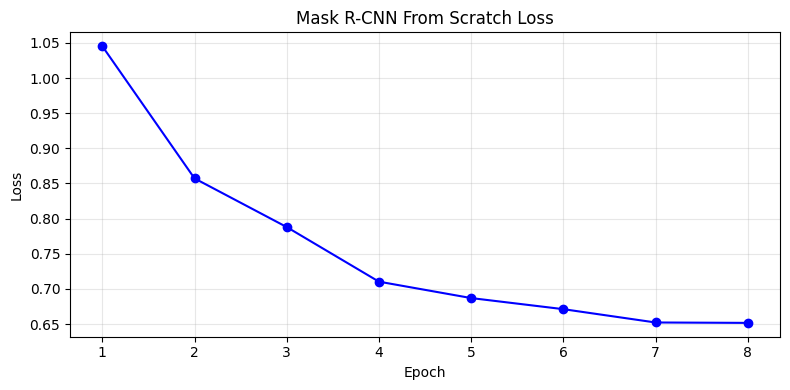

Loss curve saved.


In [10]:
torch.save(model.state_dict(), "/kaggle/working/maskrcnn_scratch.pth")
print("Saved: maskrcnn_scratch.pth")

with open("/kaggle/working/scratch_train_time.json", "w") as f:
    json.dump({"train_time_seconds": train_time}, f)

plt.figure(figsize=(8,4))
plt.plot(range(1, EPOCHS+1), train_losses, marker="o", color="blue")
plt.title("Mask R-CNN From Scratch Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("/kaggle/working/scratch_loss_curve.png", dpi=150)
plt.show()
print("Loss curve saved.")

In [11]:
model.eval()
os.makedirs("/kaggle/working/visuals_scratch", exist_ok=True)
COLORS = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),(255,0,255)]

for idx in range(min(3, len(val_data))):
    sample = val_data[idx]
    img    = cv2.imread(sample["img_path"])
    img    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img    = cv2.resize(img, (512, 512))
    inp    = F.to_tensor(Image.fromarray(img)).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(inp)[0]

    vis = img.copy()
    for i in range(len(pred["boxes"])):
        score = pred["scores"][i].item()
        if score < 0.3: continue
        box   = pred["boxes"][i].cpu().numpy().astype(int)
        lbl   = pred["labels"][i].item()
        mask  = pred["masks"][i, 0].cpu().numpy() > 0.5
        color = COLORS[(lbl - 1) % len(COLORS)]
        vis[mask] = (vis[mask]*0.5 + np.array(color)*0.5).astype(np.uint8)
        cv2.rectangle(vis, (box[0],box[1]), (box[2],box[3]), color, 2)
        cv2.putText(vis, f"{CLASS_NAMES[lbl]} {score:.2f}",
                    (box[0], max(box[1]-5,10)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    plt.figure(figsize=(8,6)); plt.imshow(vis); plt.axis("off")
    plt.title(f"Scratch — Sample {idx+1}")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/visuals_scratch/pred_{idx+1}.png", dpi=150)
    plt.close()

print("Visuals saved.")
print("Output files:", os.listdir("/kaggle/working"))

Visuals saved.
Output files: ['maskrcnn_scratch.pth', 'label_map.json', '__notebook__.ipynb', 'scratch_train_time.json', 'scratch_loss_curve.png', 'visuals_scratch']
